# Measurement Calibration Theoretical Model (Real Data)

This notebook implements the estimator described in `docs/measurement-calibration.tex` using:
- Real measured PSD data from `data/Node*-Bogota.csv`
- Real characterization error curves from `data/characterization-node*.csv`

The calibration is applied independently per node, consistent with the theoretical model.

## Model Implemented

For each node $i$ and frequency $f$:

- Measurement model in PSD: $\Phi_{y_i}(f)=|H_i(f)|^2\Phi_{x_i}(f)+\Phi_{n_i}(f)$
- Characterization curve in dB: $E_i(f)=10\log_{10}|H_i(f)|^2$

### Negligible-noise regime
If noise is negligible, calibration in dB is:
$$\widehat{S}_{x_i}(f)=S_{y_i}(f)-E_i(f).$$

### Noise-aware regime
If noise is not negligible, calibration must be performed in linear power:
$$\widehat{S}_{x_i}(f)=10\log_{10}\left(10^{S_{y_i}(f)/10}-10^{S_{n_i}(f)/10}\right)-E_i(f).$$

In this repository there is no direct measured $S_{n_i}(f)$ file, so the notebook uses the negligible-noise estimator as the main output and includes an optional noise-aware example using a rough percentile-based noise-floor estimate.

In [1]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Dict, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
# Resolve repository paths robustly whether the notebook is run from repo root or from ./test
repo_root = Path.cwd()
if not (repo_root / 'data').exists() and (repo_root.parent / 'data').exists():
    repo_root = repo_root.parent

DATA_DIR = repo_root / 'data'
DOC_PATH = repo_root / 'docs' / 'measurement-calibration.tex'

assert DATA_DIR.exists(), f'Missing data directory: {DATA_DIR}'
assert DOC_PATH.exists(), f'Missing model document: {DOC_PATH}'

print(f'Repository root: {repo_root}')
print(f'Data directory  : {DATA_DIR}')
print(f'Model document  : {DOC_PATH}')


Repository root: /home/marti/Code/MeasurementCalibration
Data directory  : /home/marti/Code/MeasurementCalibration/data
Model document  : /home/marti/Code/MeasurementCalibration/docs/measurement-calibration.tex


In [3]:
def extract_node_id_from_filename(
    file_name: str,  # File name containing a node identifier, e.g. 'Node7-Bogota.csv'
) -> int:            # Parsed node identifier as integer
    """Extracts the numeric node id from a file name.

    Purpose:
    Convert naming conventions used by measurement and characterization files into
    a common integer key (`node_id`) so both datasets can be linked robustly.

    Parameters:
    file_name: Input file name string.

    Returns:
    Node identifier as an integer.

    Side effects:
    None.

    Assumptions:
    The file name includes the token 'node' followed by digits.
    """
    match = re.search(r'node(\d+)', file_name, flags=re.IGNORECASE)
    if match is None:
        raise ValueError(f'Could not parse node id from: {file_name}')
    return int(match.group(1))


def parse_pxx_db_array(
    pxx_text: str,  # Serialized PSD vector from CSV (string list)
) -> np.ndarray:   # PSD vector in dB as float64 numpy array
    """Parses the serialized PSD column into a numeric vector.

    Purpose:
    Convert each CSV `pxx` text payload into a dense numeric array for spectral
    calibration.

    Parameters:
    pxx_text: String representation of a list of PSD values in dB.

    Returns:
    One-dimensional numpy array containing PSD samples in dB.

    Side effects:
    None.

    Assumptions:
    The string follows the format '[v1,v2,...,vN]'.
    """
    pxx_db = np.fromstring(pxx_text.strip('[]'), sep=',', dtype=np.float64)
    if pxx_db.size == 0:
        raise ValueError('Parsed PSD vector is empty. Check pxx serialization format.')
    return pxx_db


def build_frequency_axis_hz(
    start_freq_hz: float,  # Start frequency [Hz]
    end_freq_hz: float,    # End frequency [Hz]
    n_bins: int,           # Number of PSD bins [samples]
) -> np.ndarray:           # Frequency axis aligned with PSD bins [Hz]
    """Builds the frequency axis corresponding to a PSD vector.

    Purpose:
    Reconstruct the per-bin frequency values needed to align measurement PSD and
    characterization error curves.

    Parameters:
    start_freq_hz: Lower frequency bound in Hertz.
    end_freq_hz: Upper frequency bound in Hertz.
    n_bins: Number of PSD bins.

    Returns:
    Linearly spaced frequency axis with `n_bins` points in Hertz.

    Side effects:
    None.

    Assumptions:
    The PSD bins are uniformly distributed across the configured span.
    """
    if n_bins < 2:
        raise ValueError(f'n_bins must be >= 2, got {n_bins}')
    return np.linspace(start_freq_hz, end_freq_hz, n_bins, dtype=np.float64)


def load_characterization_error_curve(
    characterization_path: Path,  # Path to characterization-node*.csv
) -> pd.DataFrame:               # Clean table with numeric frequency and error columns
    """Loads and cleans the characterization error curve E_i(f).

    Purpose:
    Read per-node calibration data and remove footer summary rows
    ('Promedio', 'Desviación', 'Varianza') so interpolation is strictly numeric.

    Parameters:
    characterization_path: CSV file containing columns `central_freq_hz` and `error_dB`.

    Returns:
    DataFrame with numeric columns:
    - `freq_hz`: calibration frequency in Hertz
    - `error_db`: calibration error E_i(f) in dB

    Side effects:
    Reads a CSV file from disk.

    Assumptions:
    At least one numeric characterization row is available after cleaning.
    """
    raw_df = pd.read_csv(characterization_path, usecols=['central_freq_hz', 'error_dB'])

    # Keep only numeric frequency rows and standardize names/units.
    clean_df = pd.DataFrame()
    clean_df['freq_hz'] = pd.to_numeric(raw_df['central_freq_hz'], errors='coerce')
    clean_df['error_db'] = pd.to_numeric(raw_df['error_dB'], errors='coerce')
    clean_df = clean_df.dropna(subset=['freq_hz', 'error_db']).sort_values('freq_hz')

    if clean_df.empty:
        raise ValueError(f'No numeric characterization samples found in {characterization_path}')

    return clean_df.reset_index(drop=True)


def interpolate_error_db_to_psd_axis(
    psd_freq_hz: np.ndarray,      # PSD frequency axis [Hz]
    error_curve_df: pd.DataFrame, # Characterization curve with freq_hz/error_db
) -> np.ndarray:                 # E_i(f) interpolated to PSD axis [dB]
    """Interpolates characterization error onto the PSD frequency grid.

    Purpose:
    Align the calibration error curve and the measured PSD bins before applying
    the inverse transfer correction.

    Parameters:
    psd_freq_hz: Frequency axis of measured PSD bins.
    error_curve_df: Clean characterization table from `load_characterization_error_curve`.

    Returns:
    Error vector E_i(f) in dB with one value per PSD bin.

    Side effects:
    None.

    Assumptions:
    Out-of-range frequencies use edge-value extrapolation (constant left/right).
    """
    return np.interp(
        psd_freq_hz,
        error_curve_df['freq_hz'].to_numpy(dtype=np.float64),
        error_curve_df['error_db'].to_numpy(dtype=np.float64),
        left=error_curve_df['error_db'].iloc[0],
        right=error_curve_df['error_db'].iloc[-1],
    )


def calibrate_psd_db_negligible_noise(
    measured_psd_db: np.ndarray,  # Measured PSD S_y(f) [dB]
    error_db: np.ndarray,         # Characterization error E_i(f) [dB]
) -> np.ndarray:                 # Calibrated PSD \hat{S}_x(f) [dB]
    """Applies the negligible-noise theoretical calibration in dB.

    Purpose:
    Implement the model equation:
        S_x_hat(f) = S_y(f) - E_i(f)
    when internal noise is negligible relative to measured signal power.

    Parameters:
    measured_psd_db: Measured PSD in dB.
    error_db: Characterization error curve in dB on the same frequency grid.

    Returns:
    Calibrated PSD estimate in dB.

    Side effects:
    None.
    """
    return measured_psd_db - error_db


def calibrate_psd_db_with_noise(
    measured_psd_db: np.ndarray,      # Measured PSD S_y(f) [dB]
    error_db: np.ndarray,             # Characterization error E_i(f) [dB]
    noise_psd_db: np.ndarray,         # Noise PSD estimate S_n(f) [dB]
    min_power_linear: float = 1e-20, # Lower bound to avoid log10(0)
) -> np.ndarray:                     # Noise-aware calibrated PSD \hat{S}_x(f) [dB]
    """Applies the full theoretical calibration with explicit noise subtraction.

    Purpose:
    Implement the model equation in linear power units:
        S_x_hat = 10*log10(10^(S_y/10) - 10^(S_n/10)) - E
    ensuring numerical safety before converting back to dB.

    Parameters:
    measured_psd_db: Measured PSD in dB.
    error_db: Characterization error in dB.
    noise_psd_db: Estimated or measured noise PSD in dB.
    min_power_linear: Minimum linear power clamp to keep logarithm defined.

    Returns:
    Calibrated PSD estimate in dB including noise subtraction.

    Side effects:
    None.
    """
    measured_linear = np.power(10.0, measured_psd_db / 10.0)
    noise_linear = np.power(10.0, noise_psd_db / 10.0)

    # Enforce non-negative corrected power before converting back to dB.
    corrected_linear = np.maximum(measured_linear - noise_linear, min_power_linear)
    corrected_db = 10.0 * np.log10(corrected_linear)

    return corrected_db - error_db


def estimate_noise_floor_db(
    measured_psd_db: np.ndarray, # Measured PSD S_y(f) [dB]
    percentile: float = 5.0,     # Percentile used as noise-floor proxy [%]
) -> float:                     # Scalar noise-floor estimate [dB]
    """Estimates a simple scalar noise floor from one PSD vector.

    Purpose:
    Provide a fallback noise level when direct noise measurements are unavailable.
    This is only a demonstration helper for the noise-aware equation.

    Parameters:
    measured_psd_db: Measured PSD in dB.
    percentile: Low percentile treated as background floor.

    Returns:
    Scalar noise-floor estimate in dB.

    Side effects:
    None.
    """
    return float(np.percentile(measured_psd_db, percentile))


In [4]:
# Discover Bogota measurement files and available characterization curves
node_paths = sorted(DATA_DIR.glob('Node*-Bogota.csv'))
characterization_paths = sorted(DATA_DIR.glob('characterization-node*.csv'))

characterization_by_node: Dict[int, Path] = {
    extract_node_id_from_filename(path.name): path for path in characterization_paths
}

availability_rows = []
for node_path in node_paths:
    node_id = extract_node_id_from_filename(node_path.name)
    availability_rows.append(
        {
            'node_file': node_path.name,
            'node_id': node_id,
            'characterization_file': characterization_by_node.get(node_id, None).name if node_id in characterization_by_node else None,
            'has_characterization': node_id in characterization_by_node,
        }
    )

availability_df = pd.DataFrame(availability_rows).sort_values('node_id').reset_index(drop=True)
availability_df


,node_file,node_id,characterization_file,has_characterization
0,Node1-Bogota.csv,1,characterization-node1.csv,True
1,Node2-Bogota.csv,2,characterization-node2.csv,True
2,Node3-Bogota.csv,3,characterization-node3.csv,True
3,Node4-Bogota.csv,4,characterization-node4.csv,True
4,Node5-Bogota.csv,5,characterization-node5.csv,True
5,Node6-Bogota.csv,6,characterization-node6.csv,True
6,Node7-Bogota.csv,7,characterization-node7.csv,True
7,Node8-Bogota.csv,8,characterization-node8.csv,True
8,Node10-Bogota.csv,10,characterization-node10.csv,True


In [5]:
# Calibrate a representative real PSD row for each node (row index configurable)
ROW_INDEX = 0  # Measurement row index used for direct per-node visualization

single_row_results: Dict[str, Dict[str, np.ndarray | float]] = {}
single_row_summary = []

for node_path in node_paths:
    node_id = extract_node_id_from_filename(node_path.name)
    if node_id not in characterization_by_node:
        continue

    # Read only what is needed for the selected row to keep memory usage bounded.
    node_df = pd.read_csv(
        node_path,
        usecols=['id', 'pxx', 'start_freq_hz', 'end_freq_hz'],
        nrows=ROW_INDEX + 1,
    )
    if len(node_df) <= ROW_INDEX:
        continue

    row = node_df.iloc[ROW_INDEX]
    measured_psd_db = parse_pxx_db_array(row['pxx'])
    freq_hz = build_frequency_axis_hz(float(row['start_freq_hz']), float(row['end_freq_hz']), measured_psd_db.size)

    characterization_df = load_characterization_error_curve(characterization_by_node[node_id])
    error_db = interpolate_error_db_to_psd_axis(freq_hz, characterization_df)

    calibrated_psd_db = calibrate_psd_db_negligible_noise(measured_psd_db, error_db)

    # Optional example for the full noise-aware equation with a rough noise-floor proxy.
    noise_floor_db = estimate_noise_floor_db(measured_psd_db, percentile=5.0)
    noise_floor_vec_db = np.full_like(measured_psd_db, noise_floor_db)
    calibrated_psd_noise_db = calibrate_psd_db_with_noise(
        measured_psd_db=measured_psd_db,
        error_db=error_db,
        noise_psd_db=noise_floor_vec_db,
    )

    node_name = node_path.stem
    single_row_results[node_name] = {
        'freq_hz': freq_hz,
        'measured_psd_db': measured_psd_db,
        'error_db': error_db,
        'calibrated_psd_db': calibrated_psd_db,
        'calibrated_psd_noise_db': calibrated_psd_noise_db,
        'noise_floor_db': noise_floor_db,
    }

    single_row_summary.append(
        {
            'node': node_name,
            'row_id': int(row['id']),
            'n_bins': measured_psd_db.size,
            'start_freq_mhz': float(row['start_freq_hz']) / 1e6,
            'end_freq_mhz': float(row['end_freq_hz']) / 1e6,
            'mean_measured_db': float(np.mean(measured_psd_db)),
            'mean_calibrated_db': float(np.mean(calibrated_psd_db)),
            'mean_interpolated_error_db': float(np.mean(error_db)),
            'noise_floor_db_p05': noise_floor_db,
        }
    )

single_row_summary_df = pd.DataFrame(single_row_summary).sort_values('node').reset_index(drop=True)
single_row_summary_df


,node,row_id,n_bins,start_freq_mhz,end_freq_mhz,mean_measured_db,mean_calibrated_db,mean_interpolated_error_db,noise_floor_db_p05
0,Node1-Bogota,208061,32768,88.0,108.0,-19.843477,-12.118876,-7.724601,-23.699902
1,Node10-Bogota,208075,32768,88.0,108.0,-19.734581,-17.678414,-2.056167,-23.442842
2,Node2-Bogota,208063,32768,88.0,108.0,-19.461993,-19.570737,0.108744,-23.173414
3,Node3-Bogota,208062,32768,88.0,108.0,-19.272788,-13.588060,-5.684728,-21.423099
4,Node4-Bogota,208065,32768,88.0,108.0,-19.718683,-8.217503,-11.501180,-23.689125
5,Node5-Bogota,208067,32768,88.0,108.0,-19.460719,-13.251485,-6.209234,-22.695678
6,Node6-Bogota,208060,32768,88.0,108.0,-18.857903,-14.013075,-4.844828,-21.729881
7,Node7-Bogota,208066,32768,88.0,108.0,-19.271908,-18.804450,-0.467458,-22.959202
8,Node8-Bogota,208064,32768,88.0,108.0,-19.651653,-19.468407,-0.183246,-23.620491


In [6]:
def compute_node_mean_psd_profiles(
    node_path: Path,               # Path to Node*-Bogota.csv
    characterization_path: Path,   # Path to characterization-node*.csv
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, int]:  # freq_hz, mean_raw_db, mean_calibrated_db, n_rows
    """Computes mean raw and calibrated PSD profiles over all rows of one node.

    Purpose:
    Use the full real measurement table for each node (not only one row) and produce
    aggregate spectral profiles before and after calibration.

    Parameters:
    node_path: Measurement file path with serialized PSD rows.
    characterization_path: Characterization file path with E_i(f).

    Returns:
    freq_hz: Frequency axis in Hertz.
    mean_raw_db: Average measured PSD profile in dB.
    mean_calibrated_db: Average calibrated PSD profile in dB.
    n_rows: Number of processed rows.

    Side effects:
    Reads node and characterization CSV files from disk.

    Assumptions:
    All rows in a node file share the same start/end frequencies and PSD bin count.
    """
    node_df = pd.read_csv(node_path, usecols=['pxx', 'start_freq_hz', 'end_freq_hz'])
    if node_df.empty:
        raise ValueError(f'Node file has no rows: {node_path}')

    # Parse first row to define fixed axis and allocate running accumulators.
    first_row = node_df.iloc[0]
    first_psd_db = parse_pxx_db_array(first_row['pxx'])
    freq_hz = build_frequency_axis_hz(
        start_freq_hz=float(first_row['start_freq_hz']),
        end_freq_hz=float(first_row['end_freq_hz']),
        n_bins=first_psd_db.size,
    )

    characterization_df = load_characterization_error_curve(characterization_path)
    error_db = interpolate_error_db_to_psd_axis(freq_hz, characterization_df)

    sum_raw_db = np.zeros_like(first_psd_db, dtype=np.float64)
    sum_calibrated_db = np.zeros_like(first_psd_db, dtype=np.float64)

    # Process each real measurement row and accumulate spectral means.
    for _, row in node_df.iterrows():
        measured_psd_db = parse_pxx_db_array(row['pxx'])
        if measured_psd_db.size != first_psd_db.size:
            raise ValueError(
                f'Inconsistent PSD size in {node_path.name}: '
                f'expected {first_psd_db.size}, got {measured_psd_db.size}'
            )

        calibrated_psd_db = calibrate_psd_db_negligible_noise(measured_psd_db, error_db)
        sum_raw_db += measured_psd_db
        sum_calibrated_db += calibrated_psd_db

    n_rows = len(node_df)
    mean_raw_db = sum_raw_db / n_rows
    mean_calibrated_db = sum_calibrated_db / n_rows

    return freq_hz, mean_raw_db, mean_calibrated_db, n_rows


In [7]:
# Run full-node aggregation for all Bogota nodes with available characterization
mean_profiles_by_node: Dict[str, Dict[str, np.ndarray | int]] = {}
full_summary_rows = []

for node_path in node_paths:
    node_id = extract_node_id_from_filename(node_path.name)
    if node_id not in characterization_by_node:
        continue

    freq_hz, mean_raw_db, mean_calibrated_db, n_rows = compute_node_mean_psd_profiles(
        node_path=node_path,
        characterization_path=characterization_by_node[node_id],
    )

    mean_profiles_by_node[node_path.stem] = {
        'freq_hz': freq_hz,
        'mean_raw_db': mean_raw_db,
        'mean_calibrated_db': mean_calibrated_db,
        'n_rows': n_rows,
    }

    full_summary_rows.append(
        {
            'node': node_path.stem,
            'n_rows': n_rows,
            'mean_raw_db': float(np.mean(mean_raw_db)),
            'mean_calibrated_db': float(np.mean(mean_calibrated_db)),
            'mean_shift_db': float(np.mean(mean_calibrated_db - mean_raw_db)),
        }
    )

full_summary_df = pd.DataFrame(full_summary_rows).sort_values('node').reset_index(drop=True)
full_summary_df


,node,n_rows,mean_raw_db,mean_calibrated_db,mean_shift_db
0,Node1-Bogota,105,-19.849849,-12.125248,7.724601
1,Node10-Bogota,104,-19.589712,-17.533545,2.056167
2,Node2-Bogota,105,-19.428030,-19.536774,-0.108744
3,Node3-Bogota,105,-19.076788,-13.392060,5.684728
4,Node4-Bogota,105,-19.667646,-8.166466,11.501180
5,Node5-Bogota,105,-19.273167,-13.063934,6.209234
6,Node6-Bogota,105,-18.834363,-13.989534,4.844828
7,Node7-Bogota,105,-19.348754,-18.881296,0.467458
8,Node8-Bogota,23,-19.706680,-19.523433,0.183246


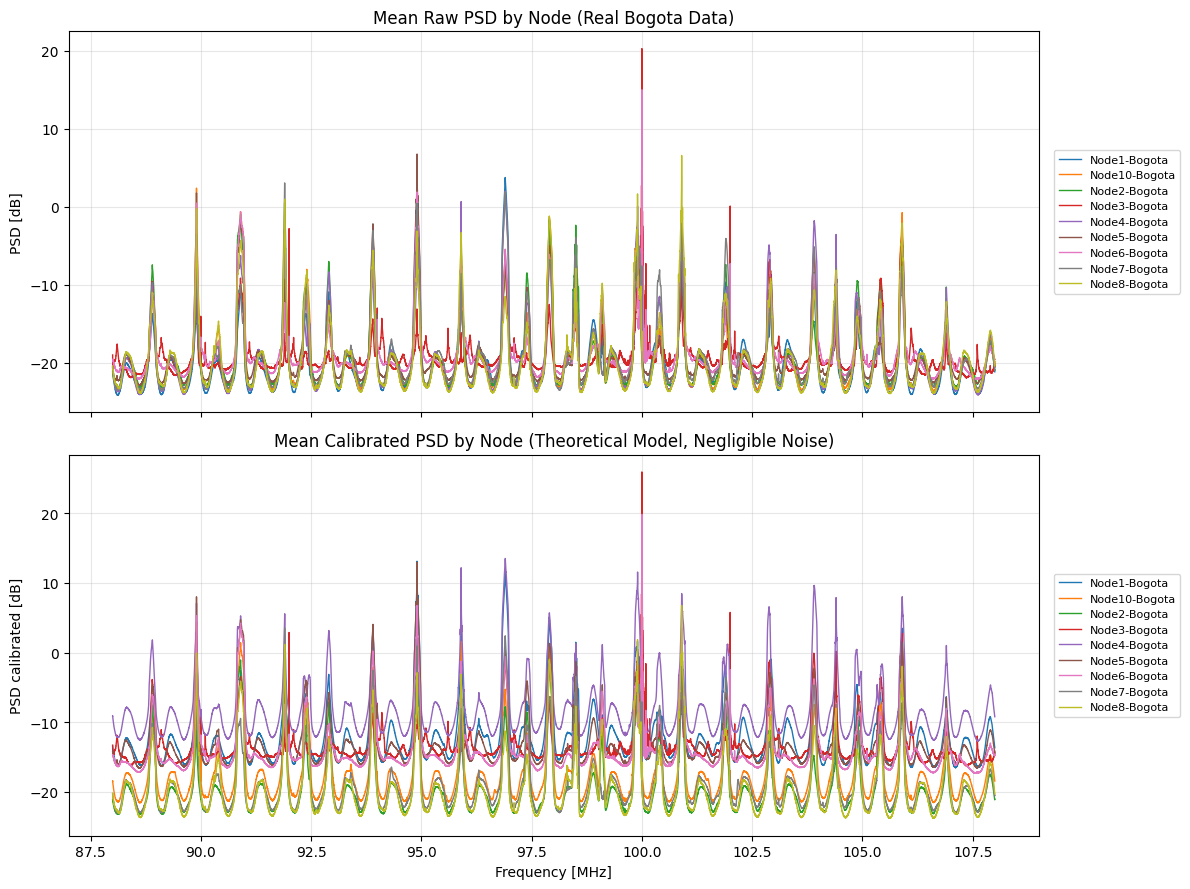

In [8]:
# Visual comparison of mean spectral profiles before/after calibration
fig, (ax_raw, ax_cal) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

for node_name, profile in sorted(mean_profiles_by_node.items()):
    freq_mhz = profile['freq_hz'] / 1e6
    ax_raw.plot(freq_mhz, profile['mean_raw_db'], label=node_name, linewidth=1.0)
    ax_cal.plot(freq_mhz, profile['mean_calibrated_db'], label=node_name, linewidth=1.0)

ax_raw.set_title('Mean Raw PSD by Node (Real Bogota Data)')
ax_raw.set_ylabel('PSD [dB]')
ax_raw.grid(True, alpha=0.3)
ax_raw.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)

ax_cal.set_title('Mean Calibrated PSD by Node (Theoretical Model, Negligible Noise)')
ax_cal.set_xlabel('Frequency [MHz]')
ax_cal.set_ylabel('PSD calibrated [dB]')
ax_cal.grid(True, alpha=0.3)
ax_cal.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)

plt.tight_layout()
plt.show()


<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_32065/182271803.py:9: SyntaxWarning: invalid escape sequence '\h'
  ax.plot(freq_mhz, selected['calibrated_psd_db'], label='Calibrated PSD $\hat{S}_x$ (negligible noise)', linewidth=1.0)
/tmp/ipykernel_32065/182271803.py:10: SyntaxWarning: invalid escape sequence '\h'
  ax.plot(freq_mhz, selected['calibrated_psd_noise_db'], label='Calibrated PSD $\hat{S}_x$ (noise-aware, estimated floor)', linewidth=1.0, alpha=0.8)


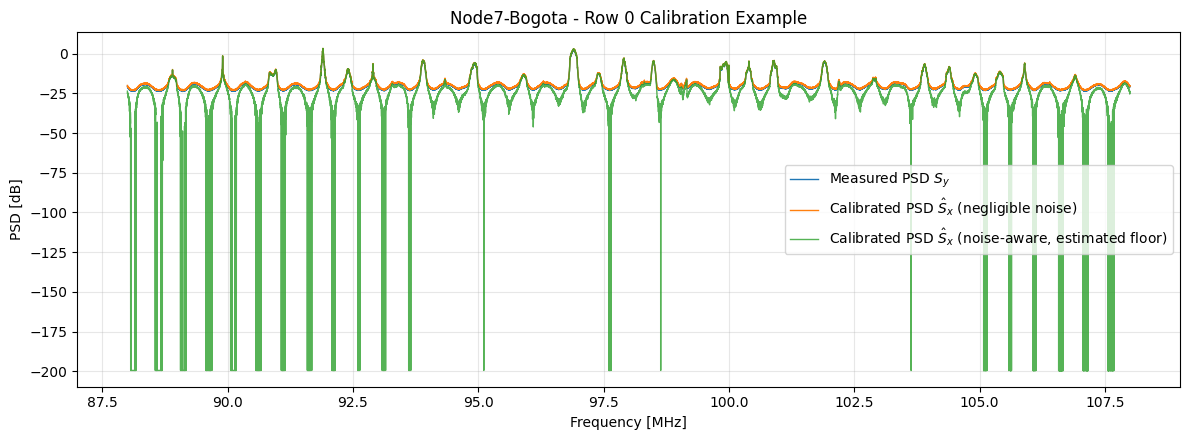

Estimated scalar noise floor for Node7-Bogota: -22.959 dB


In [9]:
# Detailed per-node example: measured vs calibrated for one selected row
SELECTED_NODE = 'Node7-Bogota'
selected = single_row_results[SELECTED_NODE]

freq_mhz = selected['freq_hz'] / 1e6

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(freq_mhz, selected['measured_psd_db'], label='Measured PSD $S_y$', linewidth=1.0)
ax.plot(freq_mhz, selected['calibrated_psd_db'], label='Calibrated PSD $\hat{S}_x$ (negligible noise)', linewidth=1.0)
ax.plot(freq_mhz, selected['calibrated_psd_noise_db'], label='Calibrated PSD $\hat{S}_x$ (noise-aware, estimated floor)', linewidth=1.0, alpha=0.8)
ax.set_title(f'{SELECTED_NODE} - Row {ROW_INDEX} Calibration Example')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('PSD [dB]')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Estimated scalar noise floor for {SELECTED_NODE}: {selected["noise_floor_db"]:.3f} dB')


## Notes on Assumptions Used in This Implementation

1. The main calibration output uses the negligible-noise estimator from the theoretical model because no direct per-node noise PSD file is provided.
2. Characterization files include textual summary rows at the end; these are removed before interpolation.
3. PSD bins below the first characterization frequency use constant edge extrapolation (`left` value in `np.interp`).
4. Calibration is applied independently per node, as stated in the model.
